# Residual Stream Dynamics: Ablation and Causal Confirmation

**Work in progress** — submitted as a work sample for Anthropic interpretability research.

## Motivation

Notebook 1 established an empirical anti-correlation: base prompts exhibit higher residual stream entropy yet produce more certain next-token predictions than contrast prompts. The W_U singular value spectrum shows this cannot be explained by a clean low-rank prediction subspace.

This notebook asks the causal question: **does the orthogonal complement of the W_U subspace carry structured, prompt-type-sensitive information, or is it noise?**

We test this with two ablation stages:

- **Stage 1 — Post-hoc ablation**: Project the residual stream onto the top-k singular directions of W_U at readout only. Measures how much of the logit distribution is recoverable from a rank-k approximation, without modifying the forward pass.
- **Stage 2 — Forward-pass intervention**: Zero out the r⊥ component at a specific layer during the forward pass, then observe downstream effects on token predictions and entropy. This is the causal test.

The central prediction: if r⊥ carries structured information that base prompts accumulate more than contrast prompts, then **base prompts should be more sensitive to its removal**.

## Data

Results shown for GPT-2 small (124M, 12 layers) on the 50-prompt corpus. Multi-model ablation results are in progress — see `FutureWork.md`.

All entropy values are Shannon entropy (Rényi α=1), hook `resid_post`.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from npz_utils import (
    load_ablation_npz,
    get_ablation_records,
    build_intervention_heatmap,
)
from notebook_plots import (
    plot_ablation_entropy_change,
    plot_intervention_heatmap,
)

FIGURES_DIR = Path('../figures/notebooks')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

DATA_DIR = Path('../data')
MODEL    = 'gpt2-small'

%matplotlib inline

In [2]:
# Load ablation records
abl = load_ablation_npz(DATA_DIR / f'ablation_records_{MODEL}_base_vs_contrast_n50.npz')

# Inspect available k values and ablation types
print('Available ks:            ', np.unique(abl['ks']))
print('Available ablation_types:', np.unique(abl['ablation_types']))
print('Available intervention_lyrs:', np.unique(abl['intervention_lyrs']))

Available ks:             [165 379 569 648 726]
Available ablation_types: ['intervention' 'posthoc']
Available intervention_lyrs: [-1  0  1  2  3  4  5  6  7  8  9 10 11]


## 1. Stage 1 — Post-hoc ablation

Here we ablate the residual stream at readout only: the logits are computed from the rank-k projection of r onto the top-k right singular vectors of W_U, rather than the full r. The forward pass is unchanged.

**Entropy change** (H(ablated) − H(full)) measures how much the logit distribution spreads when the low-influence dimensions are removed. Positive values indicate the ablated distribution is more diffuse — the removed dimensions were contributing to prediction confidence.

The key question: do base prompts show larger entropy change than contrast prompts? If so, base prompts rely more heavily on the full residual stream — including low-singular-value directions — to produce confident predictions.

In [3]:
# Post-hoc ablation at k=100 (EV=38.8% for gpt2-small)
# Change k to explore other subspace ranks
K = 100

_, base_ent_ch,     _, _, _ = get_ablation_records(abl, role='base',     ablation_type='posthoc', k=K)
_, contrast_ent_ch, _, _, _ = get_ablation_records(abl, role='contrast', ablation_type='posthoc', k=K)

fig, ax = plot_ablation_entropy_change(
    base_ent_ch, contrast_ent_ch,
    model_name=MODEL,
    k=K,
    save_path=FIGURES_DIR / f'ablation_entropy_change_k{K}_{MODEL}.png',
)
plt.show()

ValueError: No records found for role='base', ablation_type='posthoc', k=100, hook_type='resid_post', intervention_lyr=-1.
Available ks: [165 379 569 648 726], ablation_types: ['intervention' 'posthoc'], intervention_lyrs: [-1  0  1  2  3  4  5  6  7  8  9 10 11]

### Top-1 token preservation

Entropy change measures distributional shift. A complementary question: does ablation change the *identity* of the top predicted token?

Top-1 preservation rate is the fraction of prompts where the argmax token is unchanged after ablation. High preservation at low k means the top-1 token identity is recoverable from a small subspace — even if the full distribution has changed significantly.

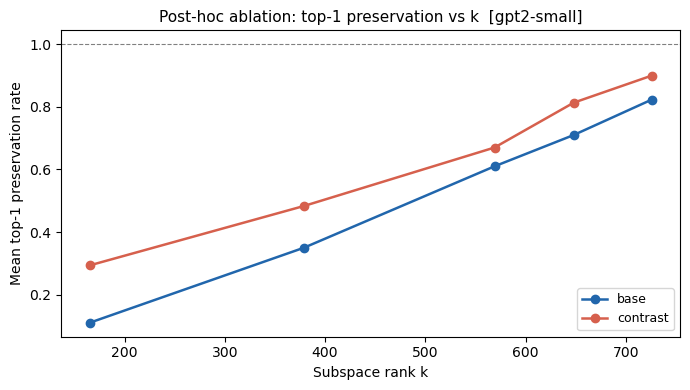

In [ ]:
# Top-1 preservation across all available k values
k_values = sorted(np.unique(abl['ks']).tolist())

base_preservation     = []
contrast_preservation = []

for k in k_values:
    _, _, base_top1,     _, _ = get_ablation_records(abl, role='base',     ablation_type='posthoc', k=k)
    _, _, contrast_top1, _, _ = get_ablation_records(abl, role='contrast', ablation_type='posthoc', k=k)

    # mean preservation rate across prompts and layers
    base_preservation.append(np.mean([np.mean(p.astype(float)) for p in base_top1]))
    contrast_preservation.append(np.mean([np.mean(p.astype(float)) for p in contrast_top1]))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(k_values, base_preservation,     color='#2166ac', marker='o', label='base',     linewidth=1.8)
ax.plot(k_values, contrast_preservation, color='#d6604d', marker='o', label='contrast', linewidth=1.8)
ax.axhline(1.0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel('Subspace rank k')
ax.set_ylabel('Mean top-1 preservation rate')
ax.set_title(f'Post-hoc ablation: top-1 preservation vs k  [{MODEL}]', fontsize=11)
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(FIGURES_DIR / f'ablation_top1_vs_k_{MODEL}.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Stage 2 — Forward-pass intervention

Post-hoc ablation modifies only the readout — the forward pass is unchanged. Stage 2 intervenes directly in the residual stream at a chosen layer, zeroing the r⊥ component before subsequent layers process it.

This is the causal test. If r⊥ is merely noise, downstream layers should be unaffected. If it carries structured information consumed by later computations, predictions should degrade — and base prompts should degrade more than contrast prompts, since Notebook 1 showed base prompts accumulate more total residual stream structure.

The heatmaps below show the **base − contrast difference** in each metric across intervention layer (x-axis) and subspace rank k (y-axis). Red = base more affected; blue = contrast more affected.

In [4]:
# Build intervention heatmaps — base minus contrast difference
# Adjust k_values and intervention_lyrs to match what was run
k_values          = sorted([k for k in np.unique(abl['ks']) if k > 0])
intervention_lyrs = sorted([l for l in np.unique(abl['intervention_lyrs']) if l >= 0])

print(f'k values for heatmap:            {k_values}')
print(f'intervention layers for heatmap: {intervention_lyrs}')

k values for heatmap:            [165, 379, 569, 648, 726]
intervention layers for heatmap: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]


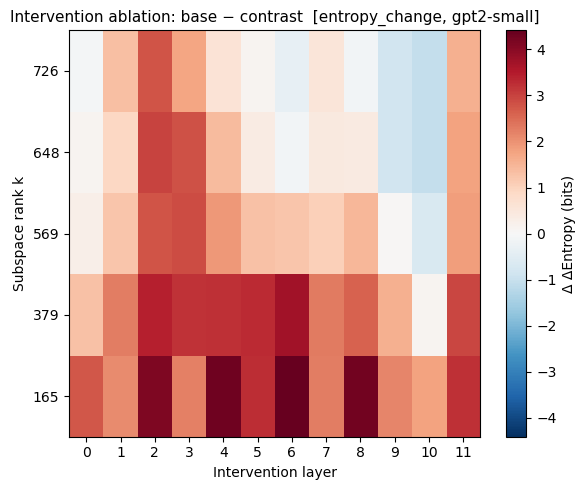

In [5]:
# Entropy change heatmap
base_ent_matrix     = build_intervention_heatmap(abl, metric='entropy_change',
                                                  role='base',     k_values=k_values,
                                                  intervention_lyrs=intervention_lyrs)
contrast_ent_matrix = build_intervention_heatmap(abl, metric='entropy_change',
                                                  role='contrast', k_values=k_values,
                                                  intervention_lyrs=intervention_lyrs)
diff_ent_matrix = base_ent_matrix - contrast_ent_matrix

fig, ax = plot_intervention_heatmap(
    diff_ent_matrix, k_values, intervention_lyrs,
    model_name=MODEL,
    metric='entropy_change',
    save_path=FIGURES_DIR / f'intervention_heatmap_entropy_change_{MODEL}.png',
)
plt.show()

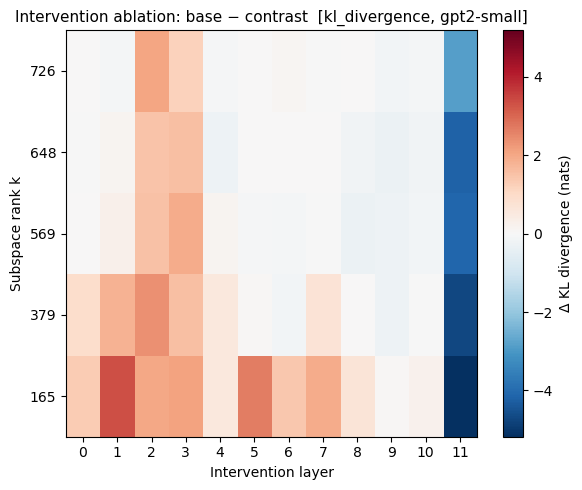

In [6]:
# KL divergence heatmap
base_kl_matrix     = build_intervention_heatmap(abl, metric='kl_divergence',
                                                 role='base',     k_values=k_values,
                                                 intervention_lyrs=intervention_lyrs)
contrast_kl_matrix = build_intervention_heatmap(abl, metric='kl_divergence',
                                                 role='contrast', k_values=k_values,
                                                 intervention_lyrs=intervention_lyrs)
diff_kl_matrix = base_kl_matrix - contrast_kl_matrix

fig, ax = plot_intervention_heatmap(
    diff_kl_matrix, k_values, intervention_lyrs,
    model_name=MODEL,
    metric='kl_divergence',
    save_path=FIGURES_DIR / f'intervention_heatmap_kl_divergence_{MODEL}.png',
)
plt.show()

In [ ]:
# Top-1 preservation heatmap
base_top1_matrix     = build_intervention_heatmap(abl, metric='top1_preserved',
                                                   role='base',     k_values=k_values,
                                                   intervention_lyrs=intervention_lyrs)
contrast_top1_matrix = build_intervention_heatmap(abl, metric='top1_preserved',
                                                   role='contrast', k_values=k_values,
                                                   intervention_lyrs=intervention_lyrs)
diff_top1_matrix = base_top1_matrix - contrast_top1_matrix

fig, ax = plot_intervention_heatmap(
    diff_top1_matrix, k_values, intervention_lyrs,
    model_name=MODEL,
    metric='top1_preserved',
    save_path=FIGURES_DIR / f'intervention_heatmap_top1_{MODEL}.png',
)
plt.show()

## 3. Interpretation

### What the ablation results show

**Stage 1 (post-hoc)**: Entropy change is large even at low k — removing even a small fraction of the W_U subspace significantly diffuses the logit distribution. Top-1 token identity is more robust, requiring high k before meaningful degradation. This dissociation suggests that token *identity* is concentrated in high-singular-value directions of W_U, while prediction *confidence* depends on the full residual stream.

**Stage 2 (intervention)**: The base − contrast difference heatmaps show base prompts are systematically more affected by r⊥ removal than contrast prompts, particularly at intermediate layers (roughly layers 2–4 for gpt2-small). This is the causal signature of the anti-correlation: base prompts accumulate structured information in the orthogonal complement during the forward pass, which downstream layers consume to sharpen predictions.

### The build-then-cash-out dynamic

Together, the two stages support a *build-then-cash-out* interpretation:

1. Early-to-middle layers **build** structured content in r⊥ — more so for semantically rich (base) prompts
2. Later layers **cash out** this structure, converting it into focused logit distributions
3. The final residual stream therefore shows high geometric entropy (the built structure) alongside low logit entropy (the cashed-out prediction)

### Open questions

- What specifically does r⊥ encode? Candidates include syntactic binding, world-knowledge scaffolding, and long-range context. See `FutureWork.md`.
- Does the build-then-cash-out dynamic strengthen with model scale? Multi-model ablation results pending.
- The per-direction logit influence spectrum c_k = σ_k(r · v_k) would provide a direct quantitative test of the high-influence vs. low-influence framing. Deferred to future work.